1. Load general dataframe

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)

PROJ = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(PROJ, "reports", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(PROJ, "data", "features.csv"), parse_dates=["collected_at"])
df = df[df["is_orphan"] == 0]
print(f"Loaded and orphans filtered... {len(df):,} rows")

Loaded and orphans filtered... 9,215,922 rows


1.1. Check dataframe

In [3]:
print(df.dtypes.to_string())
print(f"\nRows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nDate range: {df['collected_at'].min()} → {df['collected_at'].max()}")

collected_at               datetime64[us, UTC]
location_name                              str
destination_name                           str
date                                       str
is_orphan                                int64
hour                                     int64
day_of_week                              int64
is_weekend                               int64
is_rush_hour                             int64
line                                       str
location_code                              str
num_lines                                int64
is_terminal                              int64
lat                                    float64
lon                                    float64
minutes_num                            float64
num_predictions_in_feed                  int64
avg_cars_at_station                    float64
delay_rate_30min                       float64
line_delay_rate_30min                  float64
active_incident                          int64
incident_is_d

2. Create dataframe to plot

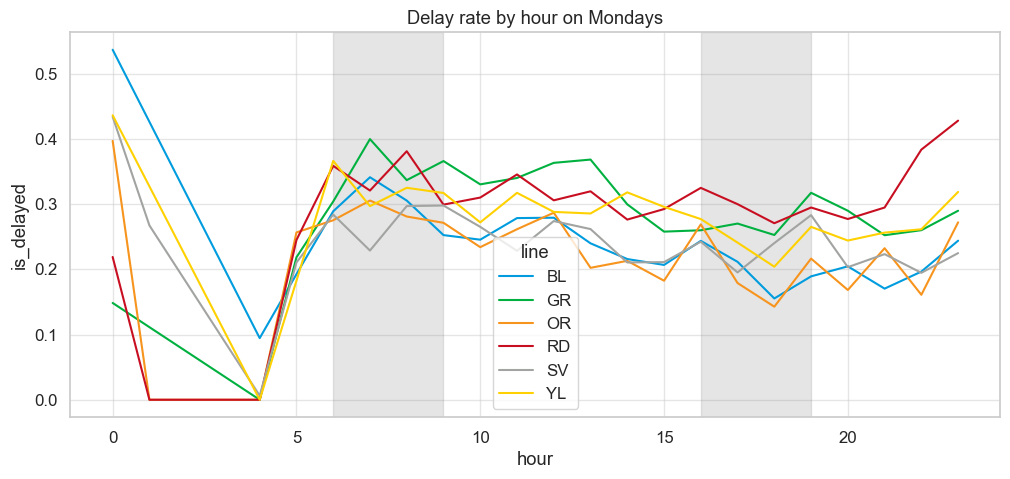

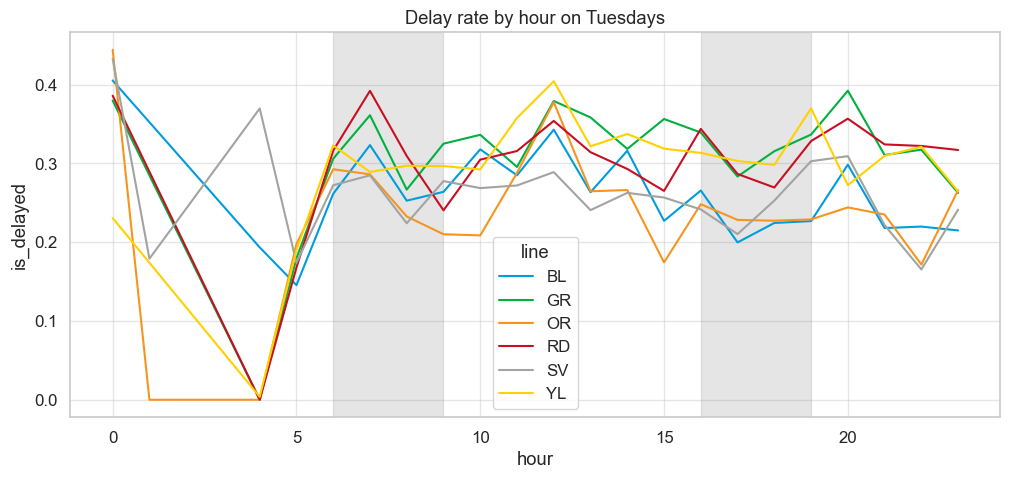

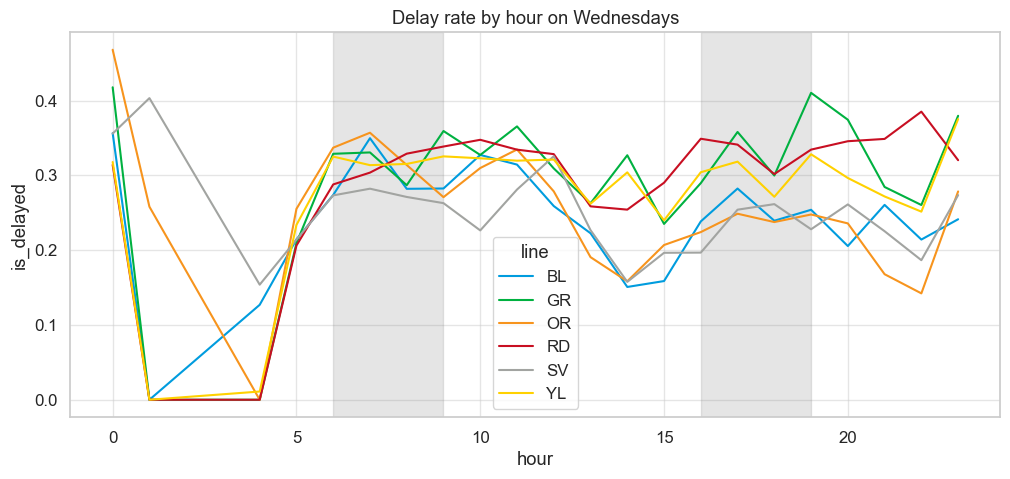

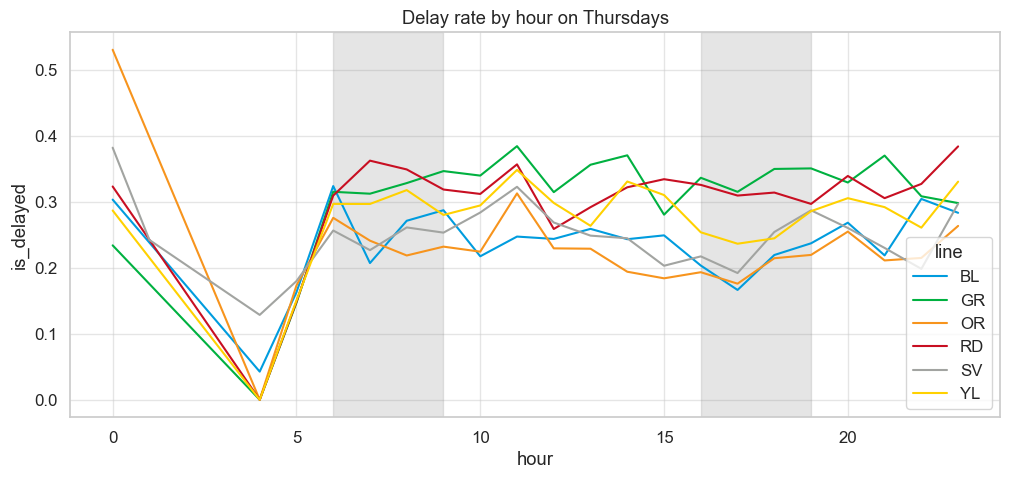

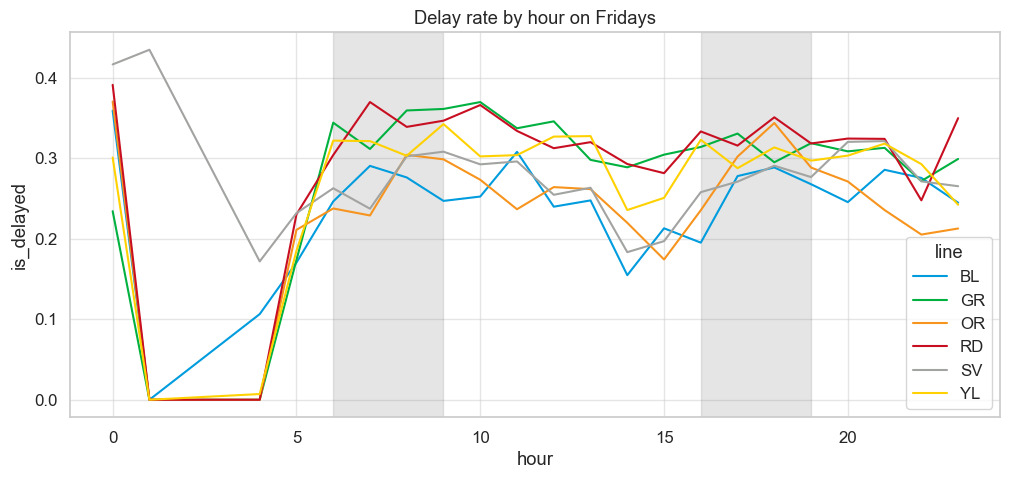

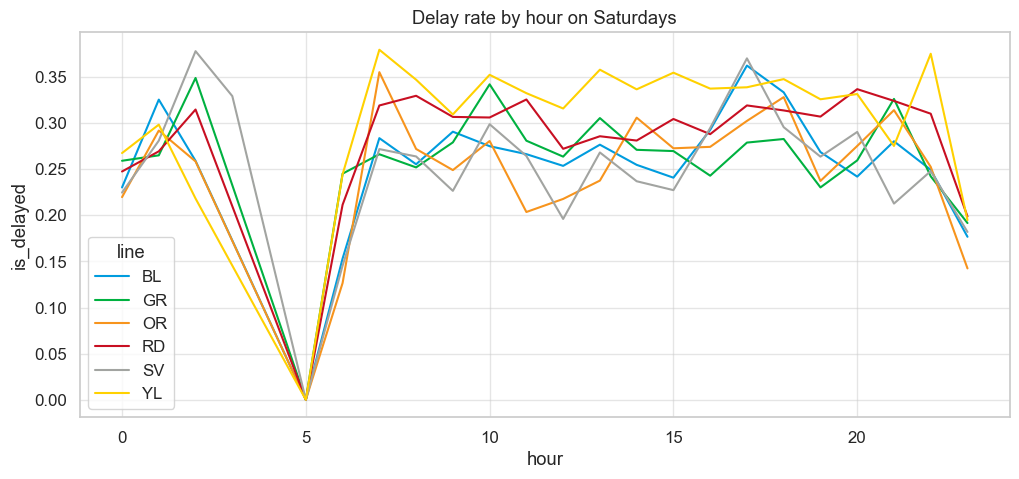

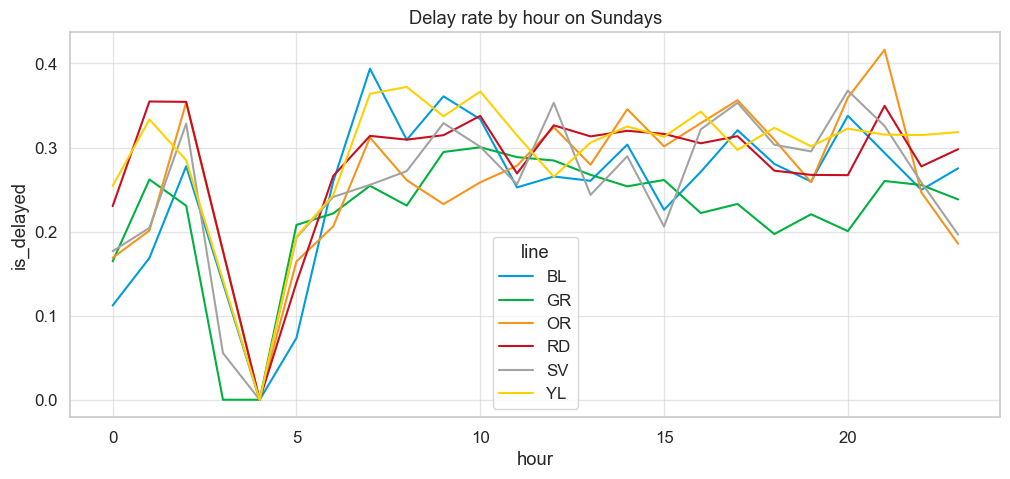

In [4]:
list_grouping = ["day_of_week", "hour", "line"]
dict_dow = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
line_colors = {"RD": "#C80F22", "BL": "#009CDE", "GR": "#00B140",
               "YL": "#FFD100", "OR": "#F7941D", "SV": "#A2A4A1"}

df_daily_delay = df.groupby(by=list_grouping, as_index=False).mean(numeric_only=True)
#print(df_daily_delay)

for num_dow, str_dow in dict_dow.items():
    df_dow_delay = (
        df_daily_delay[df_daily_delay["day_of_week"] == num_dow].
        reset_index(drop=True))
    #print(df_dow_delay)
    ax = sns.lineplot(data=df_dow_delay, x="hour", y="is_delayed", hue="line", palette=line_colors)
    if num_dow < 5:
        ax.axvspan(6, 9, color="gray", alpha=0.2)
        ax.axvspan(16, 19, color="gray", alpha=0.2)
    plt.title(f"Delay rate by hour on {str_dow}s")
    plt.show()